In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
EPS = 1e-8
epochs = np.arange(1, 21)

def real_preds(e):
    return np.array([
        max(0.55, 0.95 - 0.02*(e-1)),
        max(0.55, 0.90 - 0.02*(e-1)),
        max(0.55, 0.85 - 0.02*(e-1)),
        max(0.55, 0.80 - 0.02*(e-1)),
    ])

def fake_preds(e):
    return np.array([
        min(0.50, 0.20 + 0.02*(e-1)),
        min(0.50, 0.10 + 0.02*(e-1)),
        min(0.50, 0.15 + 0.02*(e-1)),
        min(0.50, 0.25 + 0.02*(e-1)),
    ])


In [8]:
def bce_D(R, F):
    return -0.5 * (np.mean(np.log(R+EPS)) + np.mean(np.log(1-F+EPS)))

def bce_G_saturating(F):
    return np.mean(np.log(1-F+EPS))

def bce_G_nonsaturating(F):
    return -np.mean(np.log(F+EPS))


In [9]:
rows = []
for e in epochs:
    R, F = real_preds(e), fake_preds(e)
    rows.append({
        "Epoch": e, "R1": R[0], "R2": R[1], "R3": R[2], "R4": R[3],
        "F1": F[0], "F2": F[1], "F3": F[2], "F4": F[3],
        "D_Loss": bce_D(R, F),
        "G_Loss_Saturating": bce_G_saturating(F),
        "G_Loss_NonSaturating": bce_G_nonsaturating(F)
    })
df = pd.DataFrame(rows)
df.round(4)


,Epoch,R1,R2,R3,R4,F1,F2,F3,F4,D_Loss,G_Loss_Saturating,G_Loss_NonSaturating
0,1,0.95,0.90,0.85,0.80,0.20,0.10,0.15,0.25,0.1651,-0.1947,1.7989
1,2,0.93,0.88,0.83,0.78,0.22,0.12,0.17,0.27,0.1891,-0.2193,1.6789
2,3,0.91,0.86,0.81,0.76,0.24,0.14,0.19,0.29,0.2136,-0.2446,1.5730
3,4,0.89,0.84,0.79,0.74,0.26,0.16,0.21,0.31,0.2387,-0.2706,1.4779
4,5,0.87,0.82,0.77,0.72,0.28,0.18,0.23,0.33,0.2645,-0.2972,1.3915
5,6,0.85,0.80,0.75,0.70,0.30,0.20,0.25,0.35,0.2910,-0.3246,1.3124
6,7,0.83,0.78,0.73,0.68,0.32,0.22,0.27,0.37,0.3183,-0.3527,1.2393
7,8,0.81,0.76,0.71,0.66,0.34,0.24,0.29,0.39,0.3462,-0.3817,1.1714
8,9,0.79,0.74,0.69,0.64,0.36,0.26,0.31,0.41,0.3750,-0.4115,1.1079
9,10,0.77,0.72,0.67,0.62,0.38,0.28,0.33,0.43,0.4047,-0.4423,1.0483


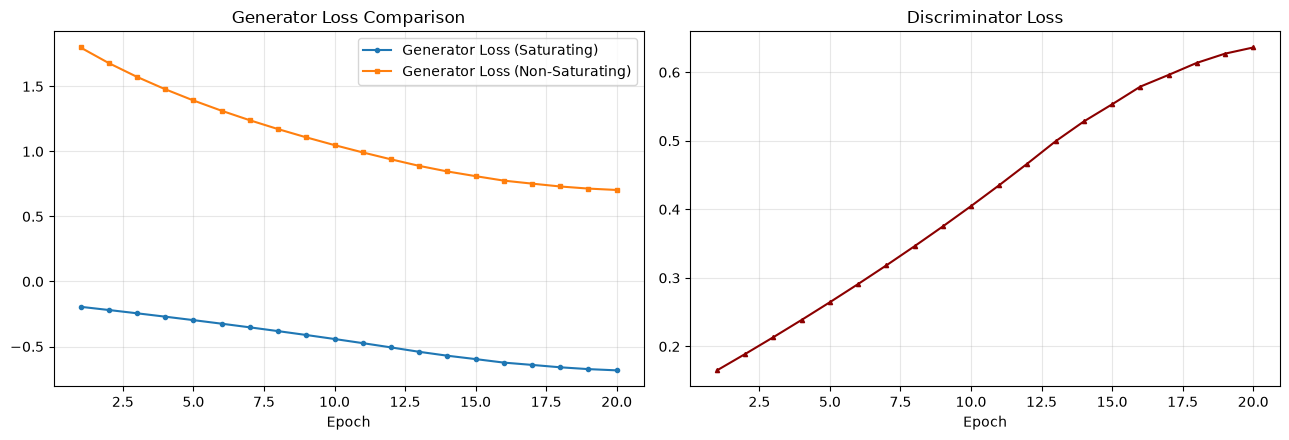

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df.Epoch, df.G_Loss_Saturating, marker='o', ms=3, label='Generator Loss (Saturating)')
axes[0].plot(df.Epoch, df.G_Loss_NonSaturating, marker='s', ms=3, label='Generator Loss (Non-Saturating)')
axes[0].set_xlabel('Epoch'); axes[0].set_title('Generator Loss Comparison'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df.Epoch, df.D_Loss, color='darkred', marker='^', ms=3)
axes[1].set_xlabel('Epoch'); axes[1].set_title('Discriminator Loss'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
def fake_preds_collapse(e):
    base = 0.08 + 0.02*np.sin(0.3*e)
    noise = np.random.normal(0, 0.003, size=4)
    return np.clip(base + noise, 0.01, 0.99)

rows_c = []
for e in epochs:
    R, F = real_preds(e), fake_preds_collapse(e)
    rows_c.append({"Epoch": e, "D_Loss": bce_D(R, F),
                    "G_Loss_NonSaturating": bce_G_nonsaturating(F),
                    "F_mean": F.mean(), "F_std": F.std()})
df_c = pd.DataFrame(rows_c)
df_c.round(4)


,Epoch,D_Loss,G_Loss_NonSaturating,F_mean,F_std
0,1,0.1137,2.4328,0.0878,0.0018
1,2,0.1280,2.3787,0.0927,0.0023
2,3,0.1412,2.3537,0.0950,0.0013
3,4,0.1537,2.3472,0.0957,0.0026
4,5,0.1673,2.3262,0.0977,0.0019
5,6,0.1811,2.3092,0.0994,0.0031
6,7,0.1926,2.3399,0.0964,0.0018
7,8,0.2046,2.3674,0.0938,0.0031
8,9,0.2150,2.4371,0.0874,0.0025
9,10,0.2256,2.5181,0.0807,0.0029


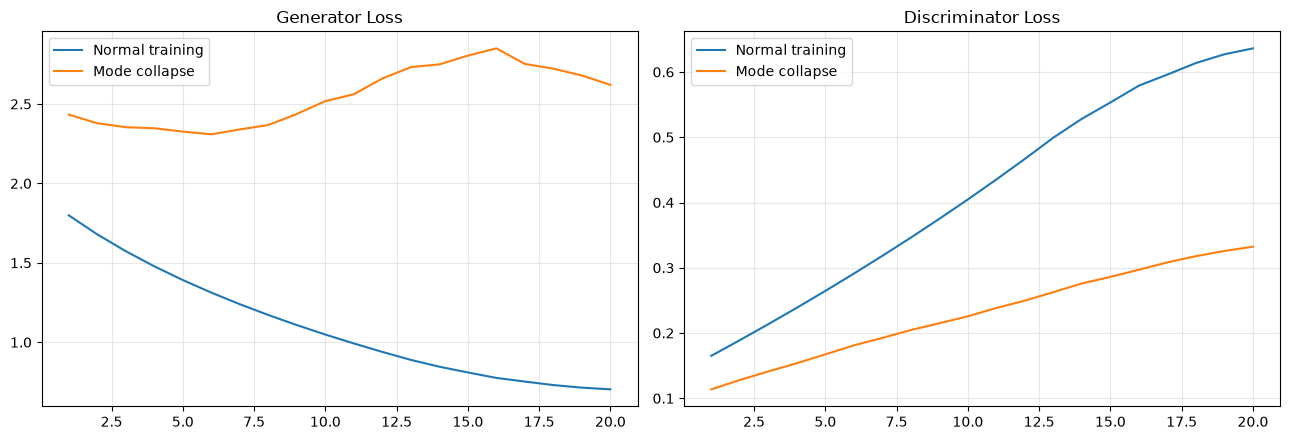

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df.Epoch, df.G_Loss_NonSaturating, label='Normal training')
axes[0].plot(df_c.Epoch, df_c.G_Loss_NonSaturating, label='Mode collapse')
axes[0].set_title('Generator Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df.Epoch, df.D_Loss, label='Normal training')
axes[1].plot(df_c.Epoch, df_c.D_Loss, label='Mode collapse')
axes[1].set_title('Discriminator Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
